# Tool Tests

Direct MCP tool tests — no LLM agent invocation. Each cell calls the MCP server
directly so you can verify tool availability, correct C# syntax, and response shapes
before wiring tools into the agent system.

**See `agent_system_tests.ipynb` for full agent graph tests with LangGraph state.**

**Prerequisites:**
- Rhino + Grasshopper running with the MCPServer component active (port 5100)
- `settings.py` configured (`MCP_GH_ENDPOINT`, etc.)
- `.env.local` configured for secret keys
- Run from the `AgentApp/` directory


In [55]:

## Setup
import os, sys, json, base64
import requests
from IPython.display import display, Image

# Notebooks live in AgentApp/notebooks/ — go up one level to reach AgentApp/
AGENT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if AGENT_ROOT not in sys.path:
    sys.path.insert(0, AGENT_ROOT)

from app.config import LLM_PROVIDER, LLM_ENDPOINT, GEMINI_MODEL, MCP_GH_ENDPOINT
print(f"Provider : {LLM_PROVIDER}")
print(f"Model    : {GEMINI_MODEL if LLM_PROVIDER == 'gemini' else LLM_ENDPOINT}")
print(f"GH MCP   : {MCP_GH_ENDPOINT}")

# ── MCP server health check ───────────────────────────────────────────────────
print()
try:
    h = requests.get(f"{MCP_GH_ENDPOINT}/api/health", timeout=3).json()
    print(f"MCP Server : ✓  ({h.get('tools', 0)} .gh tools loaded)")

    scene_raw = requests.post(
        f"{MCP_GH_ENDPOINT}/api/call_tool",
        json={"name": "get_scene_info", "arguments": {}},
        timeout=5,
    ).json()
    scene = json.loads(scene_raw.get("result") or "{}")
    doc_name = scene.get("doc_name", "?")
    doc_path = scene.get("doc_path", "")
    print(f"Rhino doc  : {doc_name}" + (f"  [{doc_path}]" if doc_path else "  (unsaved)"))
    print(f"Objects    : {scene.get('object_count', 0)}  "
          f"({', '.join(f'{v} {k}' for k, v in (scene.get('object_types') or {}).items()) or 'empty'})")
    print(f"Units      : {scene.get('units', '?')}  |  View: {scene.get('active_view', '?')}")

except requests.exceptions.ConnectionError:
    print(f"MCP Server : ✗  not reachable at {MCP_GH_ENDPOINT}")
    print("           → Start Rhino, open Grasshopper, and activate the MCPServer component.")
except Exception as e:
    print(f"MCP Server : ✗  {e}")

# ── Direct tool helper ────────────────────────────────────────────────────────
def call_tool(name: str, **kwargs) -> dict:
    """Call an MCP tool by name and return the parsed result dict."""
    resp = requests.post(
        f"{MCP_GH_ENDPOINT}/api/call_tool",
        json={"name": name, "arguments": kwargs},
        timeout=15,
    ).json()
    # HTTP-level error (e.g. tool threw an exception, tool not found)
    if resp.get("error"):
        print(f"⚠ {name} [server error]: {resp['error']}")
        return {}
    raw = resp.get("result") or "{}"
    data = json.loads(raw) if isinstance(raw, str) else raw
    # Tool-level error (e.g. run_csharp_script compilation failure)
    if not data.get("success", True):
        print(f"⚠ {name}: {data.get('error') or data.get('compilation_errors')}")
    return data


Provider : gemini
Model    : gemini-2.5-flash-lite
GH MCP   : http://localhost:5100

MCP Server : ✓  (2 .gh tools loaded)
Rhino doc  : (unsaved)  (unsaved)
Objects    : 4  (4 Brep)
Units      : Meters  |  View: Perspective


In [56]:

# ── List all tools registered on the MCP server ──────────────────────────────
from tools import TOOL_CLASSES, reload_mcp_tools

gh_tools = reload_mcp_tools()
all_tools = requests.get(f"{MCP_GH_ENDPOINT}/api/list_tools", timeout=5).json().get("tools", [])
gh_names  = {t.name for t in gh_tools}
native    = [t for t in all_tools if t["name"] not in gh_names]

print(f"Built-in tools ({len(native)}):")
for t in native:
    print(f"  • {t['name']}")

print(f"\n.gh tools ({len(gh_tools)}):")
for t in gh_tools:
    print(f"  • {t.name:30s} — {t.description[:60]}")


Built-in tools (0):

.gh tools (9):
  • capture_viewport               — Captures the active Rhino 3D viewport as a PNG and returns i
  • get_scene_info                 — Returns metadata about the current Rhino scene: document nam
  • get_selected_geometry          — Returns details about every currently selected object in the
  • bake_gh_geometry               — Bakes all current Grasshopper preview geometry into the acti
  • list_rhinocommon_types         — Introspects the loaded RhinoCommon (and Grasshopper) assembl
  • get_type_members               — Returns the public constructors, properties, and methods of 
  • run_csharp_script              — Executes arbitrary C# code using the Roslyn scripting engine
  • draw_cylinder                  — This tool create Cylinder
  • draw_square                    — This tool create Square


In [57]:

# ── Browse RhinoCommon API ────────────────────────────────────────────────────
# Step A: find types in a namespace (or search by name)
result = call_tool("list_rhinocommon_types", namespace="Rhino.Geometry", search="")
for line in result.get("types", []):
    print(line)


{'full_name': 'Rhino.Geometry.AngularDimension', 'name': 'AngularDimension', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.AnnotationBase', 'name': 'AnnotationBase', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.AnnotationType', 'name': 'AnnotationType', 'namespace': 'Rhino.Geometry', 'kind': 'enum'}
{'full_name': 'Rhino.Geometry.Arc', 'name': 'Arc', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.ArcCurve', 'name': 'ArcCurve', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.AreaMassProperties', 'name': 'AreaMassProperties', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.Arrowhead', 'name': 'Arrowhead', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.BezierCurve', 'name': 'BezierCurve', 'namespace': 'Rhino.Geometry', 'kind': 'class'}
{'full_name': 'Rhino.Geometry.BezierSurface', 'name': 'BezierSurface', 

In [58]:

# ── Get members of a specific RhinoCommon type ────────────────────────────────
# Change TYPE_NAME to any type from the list above.
TYPE_NAME = "Rhino.Geometry.Brep"

result = call_tool("get_type_members", type_name=TYPE_NAME)
print(result.get("summary", ""))


---
## 2 · Direct RhinoCommon API Tests (run_csharp_script)

Creates a box, moves it, and captures the viewport — all via direct MCP calls,
no LLM involved. Confirms C# syntax is correct before using these scripts in the agent.


In [59]:

# ── Step 1: create a box directly via MCP (bypasses LLM — known-correct C#) ──
SCRIPT = (
    "var box = new Box(new BoundingBox(new Point3d(0,0,0), new Point3d(10,8,5)));\n"
    "var id = Doc.Objects.AddBrep(box.ToBrep());\n"
    "Doc.Views.Redraw();\n"
    "id"           # last expression → returned as return_value
)

resp = requests.post(
    f"{MCP_GH_ENDPOINT}/api/call_tool",
    json={"name": "run_csharp_script", "arguments": {"code": SCRIPT}},
    timeout=10,
).json()

result = json.loads(resp.get("result", "{}"))
box_guid = json.loads(result["return_value"]) if result.get("return_value") else None
print(f"success  : {result.get('success')}")
if result.get("compilation_errors"):
    print(f"errors   : {result['compilation_errors']}")
print(f"box GUID : {box_guid}")

msgs = []
msgs += [{"role": "user", "content": "create box"}, {"role": "assistant", "content": f"Created box with GUID {box_guid}"}]


success  : True
box GUID : a520f855-5e77-413f-a34c-3f1bbfa00d8b


In [60]:

# ── Step 2: move the box 5 units in X ────────────────────────────────────────
assert box_guid, "Run step 1 first"

MOVE_SCRIPT = "\n".join([
    f'var obj = Doc.Objects.FindId(new Guid("{box_guid}"));',
     'Doc.Objects.Transform(obj.Id, Transform.Translation(new Vector3d(5,0,0)), true);',
     'Doc.Views.Redraw();',
     'true',
])
result = call_tool("run_csharp_script", code=MOVE_SCRIPT)
print(f"success : {result.get('success')}")
if result.get("error"):
    print(f"error   : {result['error']}")


success : True


view : Perspective  1024×768


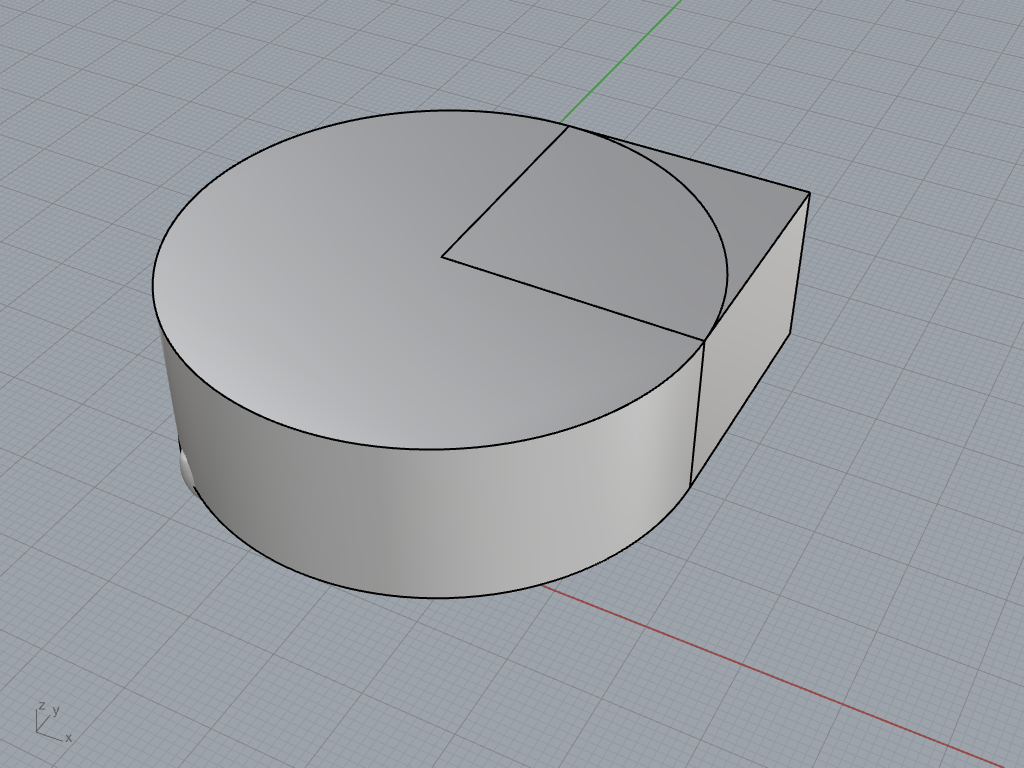

In [61]:

# ── Step 3: capture viewport ──────────────────────────────────────────────────
result = call_tool("capture_viewport", width=1024, height=768)
print(f"view : {result.get('view_name')}  {result.get('width')}×{result.get('height')}")
if result.get("image_base64"):
    display(Image(data=base64.b64decode(result["image_base64"])))


---
## 3 · Use a GH Tool

Tests routing to `use_tool` → `execute_gh_tool` where the agent picks a `.gh`-backed tool  
(e.g. `draw_cylinder` from the image).  
Make sure the MCPServer is active and the `.gh` file is in the watched folder.

In [62]:
# Show what GH tools are currently loaded from the MCP server
from tools import TOOL_CLASSES
if TOOL_CLASSES:
    print(f"{len(TOOL_CLASSES)} GH tool(s) loaded:")
    for t in TOOL_CLASSES:
        print(f"  • {t.name:30s} — {t.description[:70]}")
else:
    print("⚠ No GH tools loaded — is the Grasshopper MCPServer component running?")

9 GH tool(s) loaded:
  • capture_viewport               — Captures the active Rhino 3D viewport as a PNG and returns it as a bas
  • get_scene_info                 — Returns metadata about the current Rhino scene: document name and path
  • get_selected_geometry          — Returns details about every currently selected object in the Rhino sce
  • bake_gh_geometry               — Bakes all current Grasshopper preview geometry into the active Rhino d
  • list_rhinocommon_types         — Introspects the loaded RhinoCommon (and Grasshopper) assemblies via .N
  • get_type_members               — Returns the public constructors, properties, and methods of a .NET typ
  • run_csharp_script              — Executes arbitrary C# code using the Roslyn scripting engine directly 
  • draw_cylinder                  — This tool create Cylinder
  • draw_square                    — This tool create Square


In [63]:

# ── Direct GH tool call (draw_cylinder) ──────────────────────────────────────
cyl_tool = next((t for t in gh_tools if "cylinder" in t.name.lower()), None)
if cyl_tool:
    print(f"Tool : {cyl_tool.name}")
    print(f"Args : {list(cyl_tool.args.keys())}")
    result = cyl_tool._run(radius=30, height=20)
    print(result[:500])
else:
    print("⚠ No cylinder tool found — check the MCPServer watched folder")


Tool : draw_cylinder
Args : ['Plane', 'Radius', 'Height']
Geometry: Closed Brep
baked_guid: 7cb75ffb-8a51-4560-b5b3-c7add50cb051


In [64]:
# ── Reload GH tools (use after changing .gh files while notebook is open) ────
from tools import reload_mcp_tools
tools = reload_mcp_tools()
print(f"Reloaded — {len(tools)} tool(s) available")

Reloaded — 9 tool(s) available



---
## 4 · Use Native Tools

Native tools are built-in C# tools registered in `NativeToolRegistry`.
No `.gh` file needed — always available when the MCPServer is running.

**Inspection / viewport**
- `capture_viewport` — screenshot as base64 PNG
- `get_scene_info` — list all objects in the document (with GUIDs)
- `get_selected_geometry` — geometry of currently selected objects

**Grasshopper**
- `bake_gh_geometry` — bake active GH preview geometry into the doc

**API discovery (use before scripting)**
- `list_rhinocommon_types` — browse namespaces / find types by name
- `get_type_members` — read constructor & method signatures for any type

**Unlimited RhinoCommon scripting**
- `run_csharp_script` — execute arbitrary C# inside Rhino via Roslyn  
  `Doc` is pre-injected; auto-imports `Rhino.Geometry`, `System.Linq`, etc.  
  Last expression is JSON-serialized and returned as `return_value`.


In [65]:

# ── 4a: get_scene_info ───────────────────────────────────────────────────────
info = call_tool("get_scene_info")
print(f"doc     : {info.get('doc_name')}  units={info.get('units')}")
print(f"objects : {info.get('object_count')}  {info.get('object_types')}")
for obj in (info.get("objects") or [])[:10]:
    print(f"  {obj['id'][:8]}…  {obj['type']:12s}  layer={obj['layer']}  name={obj['name'] or '—'}")


doc     : (unsaved)  units=Meters
objects : 7  {'Brep': 7}
  7cb75ffb…  Brep          layer=Default  name=—
  0139a479…  Brep          layer=Default  name=—
  a520f855…  Brep          layer=Default  name=—
  be9480d4…  Brep          layer=Default  name=—
  642d4ad2…  Brep          layer=Default  name=—
  78700abf…  Brep          layer=Default  name=—
  c547fdc8…  Brep          layer=Default  name=—


view : Perspective  1024×768


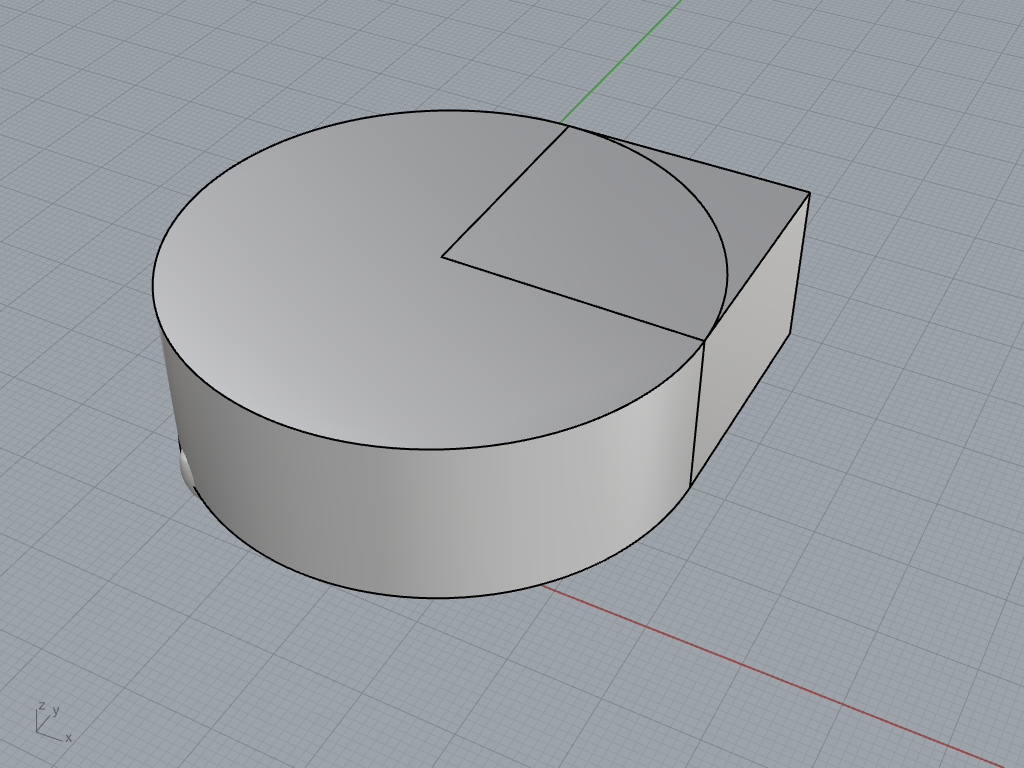

In [66]:

# ── 4b: capture_viewport ─────────────────────────────────────────────────────
result = call_tool("capture_viewport", width=1024, height=768)
print(f"view : {result.get('view_name')}  {result.get('width')}×{result.get('height')}")
if result.get("image_base64"):
    display(Image(data=base64.b64decode(result["image_base64"])))
else:
    print("⚠ No image returned — keys in result:", list(result.keys()))


In [67]:

# ── 4b-vlm: ask the VLM to reason about the captured image ───────────────────
# Requires cell above to have run successfully (result["image_base64"] must exist).
from utils.llm_utils import reason_about_image

if result.get("image_base64"):
    # Optional: customise the question
    question = "What 3D geometry do you see? Describe the shapes, positions, and any notable features."
    analysis = reason_about_image(
        result["image_base64"],
        question=question,
        view_name=result.get("view_name", ""),
    )
    print(analysis)
else:
    print("⚠ No image to analyse — run the capture cell first.")


The 3D geometry I see is a **cylinder with a quarter-circle sector removed from its top face, and a rectangular prism attached to the side of the cylinder**.

Here's a more detailed breakdown:

*   **Cylinder:**
    *   It's a standard cylinder with a circular base and a curved side.
    *   The top face of the cylinder is where the modification occurs.
    *   There's a visible coordinate system in the lower left corner, indicating the X, Y, and Z axes.

*   **Modification on the Cylinder's Top Face:**
    *   A **quarter-circle sector** has been removed from the top face of the cylinder. This is defined by two radial lines and a curved arc.
    *   A **square** is also present on the top face, with one corner at the center of the cylinder's top face and two sides aligned with the radial lines of the removed sector. This square appears to be the boundary for the removed sector.

*   **Attached Rectangular Prism:**
    *   A **rectangular prism** is attached to the side of the cylinder